In [15]:
#Import the train.csv and test.csv
import pandas as pd
df = pd.read_csv("train.csv")
df.head()
df.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


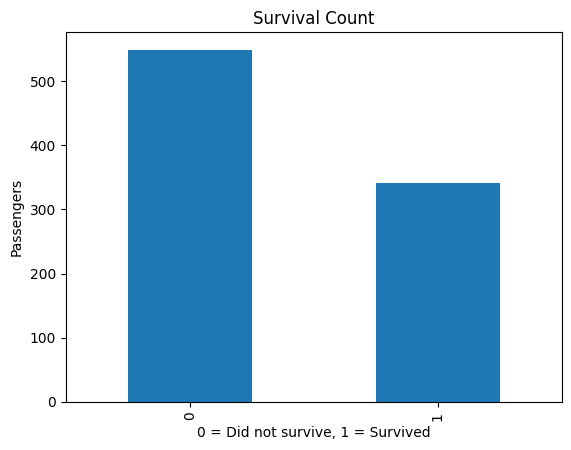

In [16]:
#visualize the survival count
import matplotlib.pyplot as plt
df['Survived'].value_counts().plot(kind='bar')
plt.title("Survival Count")
plt.xlabel("0 = Did not survive, 1 = Survived")
plt.ylabel("Passengers")
plt.show()

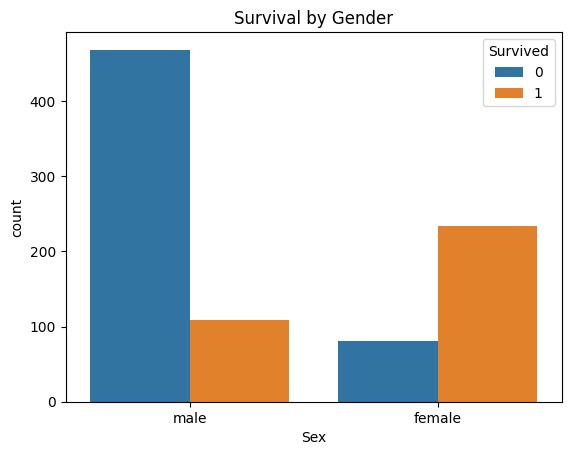

In [17]:
#visualize the survival by gender
import seaborn as sns
sns.countplot(x='Sex', hue='Survived', data=df)
plt.title("Survival by Gender")
plt.show()


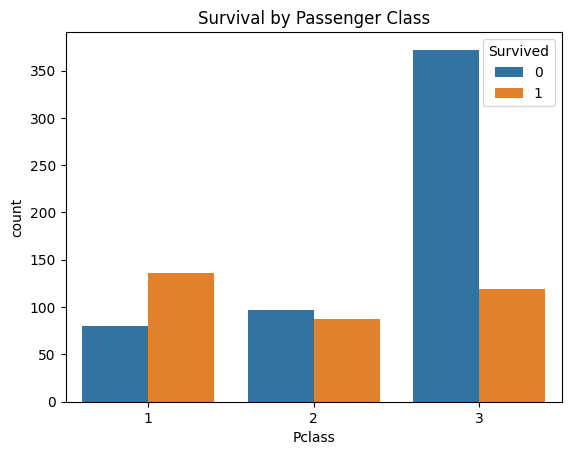

In [18]:
#Visualize the survival by passenger class
sns.countplot(x='Pclass', hue='Survived', data=df)
plt.title("Survival by Passenger Class")
plt.show()


In [19]:
# Prepare the data for training

# Handle missing values
df['Age'].fillna(df['Age'].median(), inplace=True)

# Convert categorical values to numeric values
df['Sex'] = df['Sex'].map({'male': 0, 'female': 1})

# Drop the unuseful columns
df = df.drop(['Name', 'Ticket', 'Cabin', 'Embarked'], axis=1)

# Add FamilySize and IsAlone features
df['FamilySize'] = df['SibSp'] + df['Parch'] + 1
df['IsAlone'] = 0
df.loc[df['FamilySize'] == 1, 'IsAlone'] = 1

#drop SibSp and Parch
df = df.drop(['SibSp', 'Parch'], axis=1)

# Check for any missing values
print(df.isnull().sum())


PassengerId    0
Survived       0
Pclass         0
Sex            0
Age            0
Fare           0
FamilySize     0
IsAlone        0
dtype: int64


/tmp/ipython-input-2077757489.py:4: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Age'].fillna(df['Age'].median(), inplace=True)


In [20]:
# Train the supervised model
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

# Separate features and labels
X = df.drop('Survived', axis=1)
y = df['Survived']

# Split dataset into training and validation (80% train, 20% validation)
X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, random_state=42
)

#train the Logistic Regression model
model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)


LogisticRegression(max_iter=1000)

Validation Accuracy:  0.8100558659217877
Confusion Matrix:
 [[92 13]
 [21 53]]


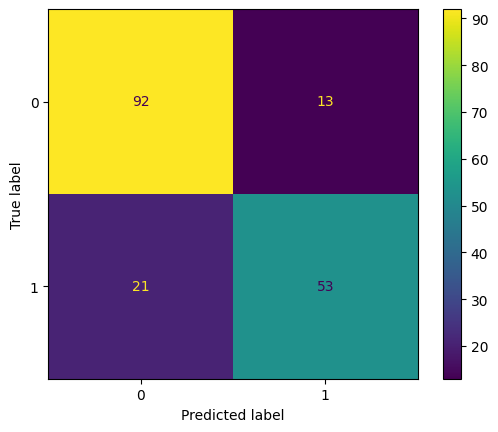

In [21]:
# Report the accuracy of the model

# Predict on the validation set
y_pred = model.predict(X_val)

# Calculate accuracy
from sklearn.metrics import accuracy_score
accuracy = accuracy_score(y_val, y_pred)
print("Validation Accuracy: ", accuracy)

#Confusion Matrix
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm = confusion_matrix(y_val, y_pred)
print("Confusion Matrix:\n", cm)

ConfusionMatrixDisplay.from_estimator(model, X_val, y_val)
plt.show()
